# About The Data

In [12]:
import pandas as pd
import numpy as np

data_file_path = "../data/MNIST_CSV/mnist_train.csv"

df = pd.read_csv(data_file_path)

df.head(5)

,5,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.608,0.609,0.610,0.611,0.612,0.613,0.614,0.615,0.616,0.617
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
Y = df.iloc[0:, 0:1]
x = df.iloc[0:, 1:] / 255

x = x.to_numpy()
Y = Y.to_numpy()
print(x.shape, Y.shape)

(59999, 784) (59999, 1)


In [14]:
Y_1d = Y.flatten()

import pandas as pd
import matplotlib.pyplot as plt

y_series = pd.Series(Y_1d)
y_counts = y_series.value_counts().sort_index()

In [15]:
y_counts

0    5923
1    6742
2    5958
3    6131
4    5842
5    5420
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64

In [16]:
y_counts.sum()

np.int64(59999)

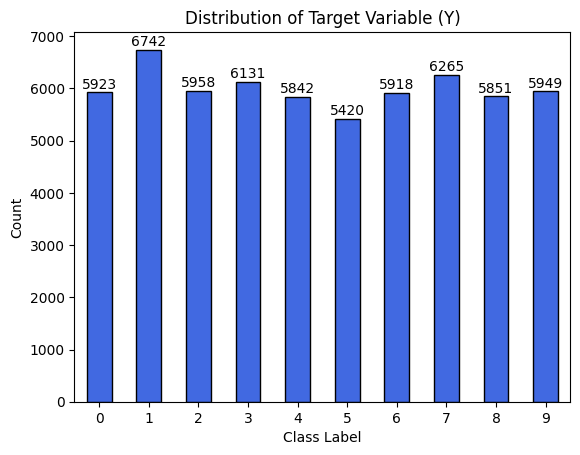

In [17]:
y_counts.plot(kind='bar', color='royalblue', edgecolor='black')

for i, count in enumerate(y_counts):
    plt.text(i, count + (max(y_counts)*0.01), str(count), ha='center')

plt.title("Distribution of Target Variable (Y)")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Check The Data

In [18]:
x = x.reshape(59999, 1, 28, 28)

nb_classes = 10
one_hot_targets = np.eye(nb_classes)[Y]
one_hot_targets = one_hot_targets.reshape(one_hot_targets.shape[0], -1)

In [19]:
x.shape, one_hot_targets.shape

((59999, 1, 28, 28), (59999, 10))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


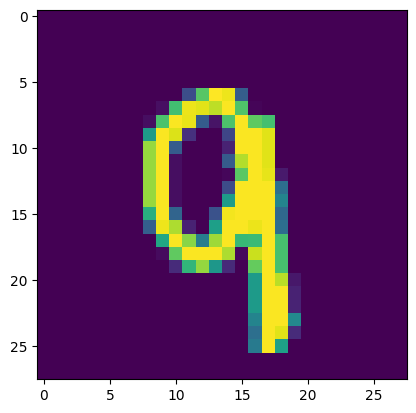

In [20]:
from matplotlib import pyplot as plt

random_choice = np.random.randint(0, 5999)
print(one_hot_targets[random_choice])
plt.imshow(x[random_choice][0])
plt.show()

# Random Sampling Data Each Label

In [24]:
import numpy as np
import pandas as pd

n_samples = 100

y_series = pd.Series(Y.flatten())

random_indices = (
    y_series.groupby(y_series)
    .apply(lambda x: x.sample(n=n_samples, random_state=42))
    .index.get_level_values(1)
)

x_sampled = x[random_indices]
Y_sampled = Y[random_indices]

print("Dimensi X baru:", x_sampled.shape)
print("Dimensi Y baru:", Y_sampled.shape)

Dimensi X baru: (1000, 1, 28, 28)
Dimensi Y baru: (1000, 1)


# Export Data as Hex

In [34]:
import numpy as np

def generate_mem_files(pixel_data, label, file_index):
    flat_data = pixel_data.reshape(-1)
    folder_path = f"./image-hex-gen/mnist_img_{label}"
    file_path = f"{folder_path}/img_{file_index}.mem"
    with open(file_path, "w") as f:
        for pixel in flat_data:
            val = int(np.clip(pixel * 255, 0, 255))
            f.write(f"{val:02X}\n")


In [35]:
Y_labels = Y_sampled.flatten()

for i in range(len(x_sampled)):
    current_image = x_sampled[i]
    current_label = Y_labels[i]
    
    generate_mem_files(current_image, current_label, file_index=i)

print(f"Selesai! Semua file .mem untuk {len(x_sampled)} sampel gambar telah dibuat.")


Selesai! Semua file .mem untuk 1000 sampel gambar telah dibuat.
